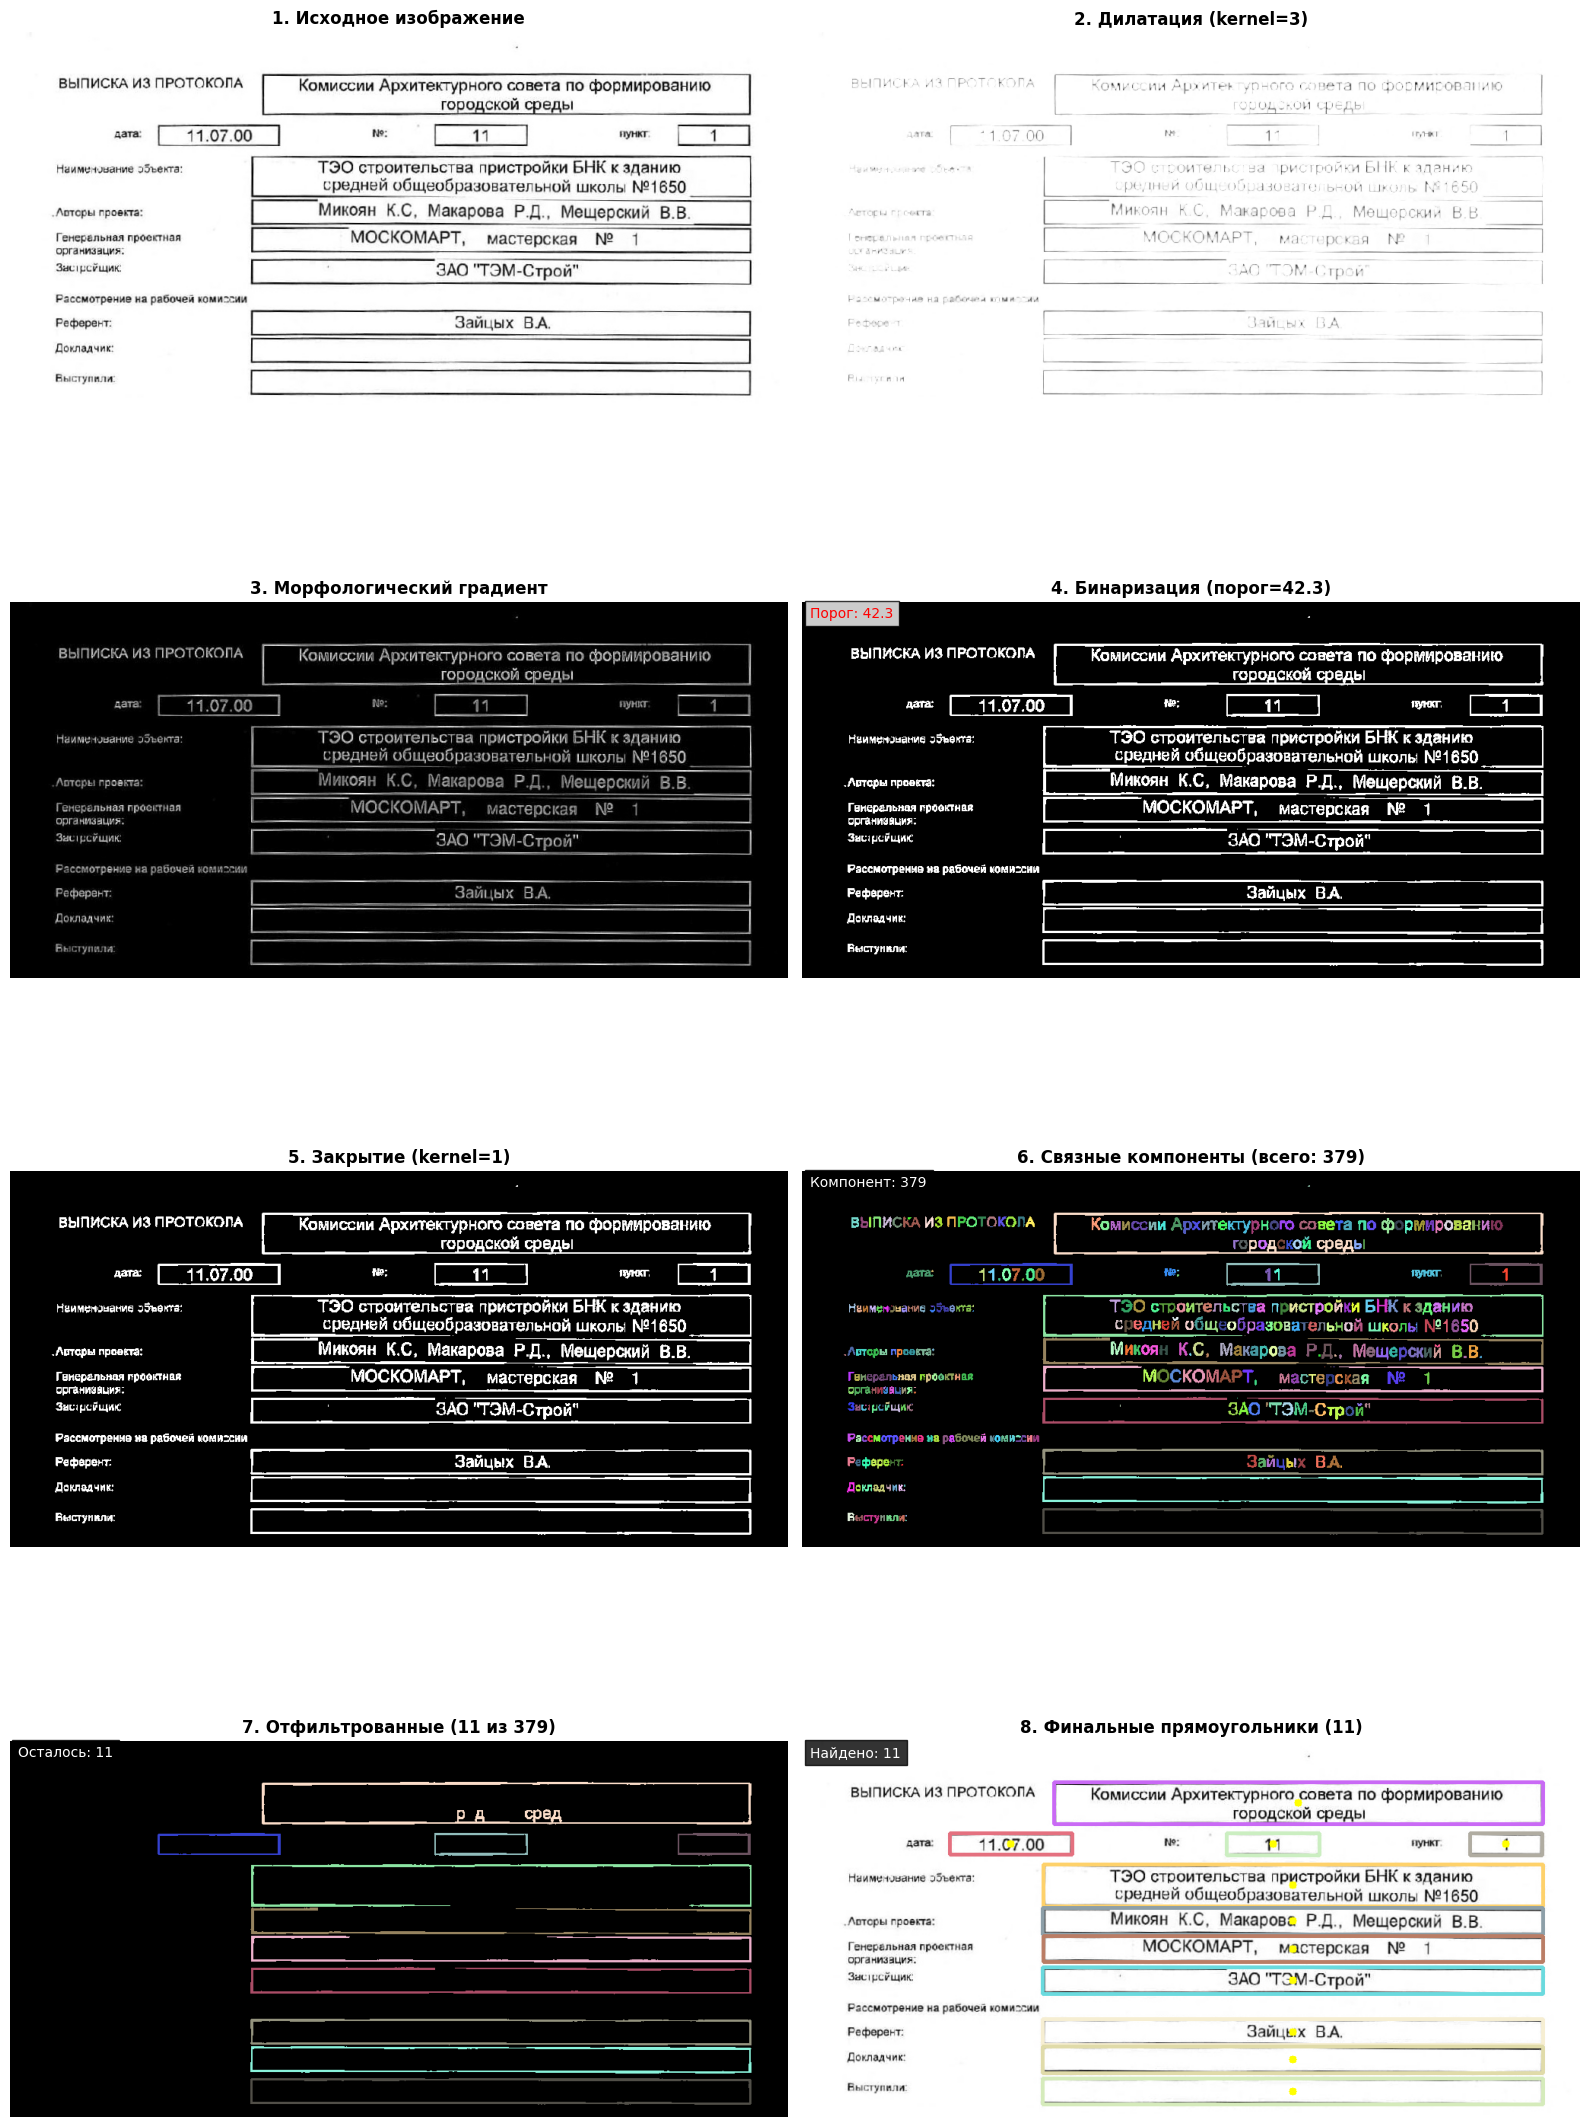

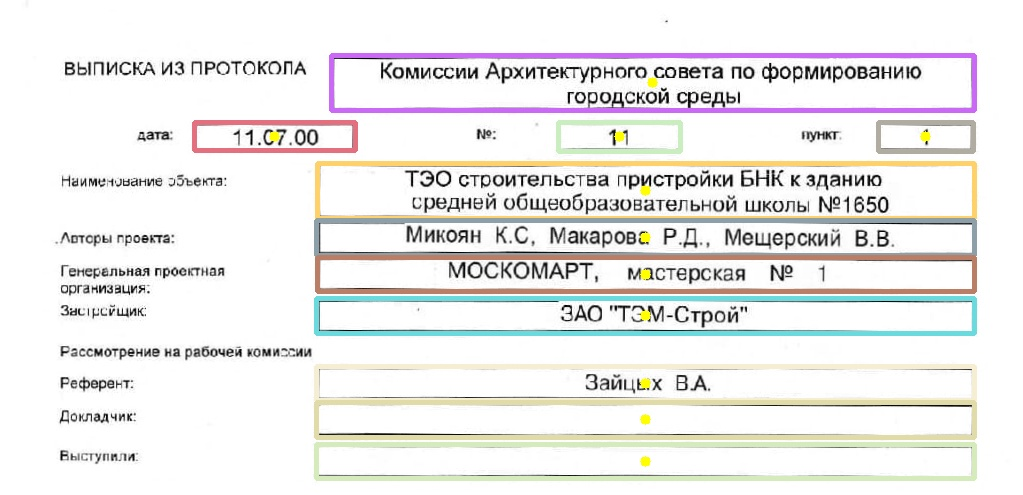

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import morphology, label, binary_closing, binary_dilation, binary_erosion
import ipywidgets as widgets
from IPython.display import display, clear_output, Image as IPImage
import random
from pathlib import Path

# ======================= ОСНОВНАЯ ФУНКЦИЯ С УЛУЧШЕННОЙ ОБРАБОТКОЙ ==================================
def box_extraction_robust(img_path, 
                          dilation_size=5,           # Размер дилатации
                          close_size=7,              # Размер закрытия
                          std_multiplier=0.8,        # Множитель порога
                          min_size=500,              # Минимальная площадь
                          use_closing=True,          # Использовать закрытие
                          use_extra_dilation=False,  # Дополнительная дилатация
                          show_debug=True):          # Показывать этапы
    
    # ============ 1. ЗАГРУЗКА ИЗОБРАЖЕНИЯ ============
    img = cv2.imread(img_path, 0)
    if img is None:
        print(f"Ошибка: не удалось загрузить {img_path}")
        return None
    
    img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    
    # ============ ДЕБАГ: СОХРАНЯЕМ ВСЕ ЭТАПЫ ============
    debug_images = []
    debug_names = []
    
    # 1. Исходное изображение
    debug_images.append(img.copy())
    debug_names.append("1. Исходное изображение")
    
    # ============ 2. МОРФОЛОГИЧЕСКИЙ ГРАДИЕНТ ============
    # 2.1 Дилатация
    footprint = np.ones((dilation_size, dilation_size), dtype=bool)
    dilated = morphology.grey_dilation(img, footprint=footprint)
    debug_images.append(dilated.copy())
    debug_names.append(f"2. Дилатация (kernel={dilation_size})")
    
    # 2.2 Вычитание (градиент)
    im_gradient = dilated.astype(np.int32) - img.astype(np.int32)
    im_gradient = np.clip(im_gradient, 0, 255).astype(np.uint8)
    debug_images.append(im_gradient.copy())
    debug_names.append("3. Морфологический градиент")
    
    # ============ 3. БИНАРИЗАЦИЯ ============
    mean, std = im_gradient.mean(), im_gradient.std()
    t = mean + (std * std_multiplier)
    
    im_binary = im_gradient.copy()
    im_binary[im_binary < t] = 0
    im_binary[im_binary >= t] = 255
    debug_images.append(im_binary.copy())
    debug_names.append(f"4. Бинаризация (порог={t:.1f})")
    
    # ============ 4. МОРФОЛОГИЧЕСКОЕ ЗАКРЫТИЕ (заполнение пропусков) ============
    im_closed = im_binary.copy()
    
    if use_closing:
        # Создаем структурный элемент для закрытия
        struct_close = np.ones((close_size, close_size), dtype=bool)
        
        # Применяем бинарное закрытие (дилатация + эрозия)
        im_binary_bool = im_binary.astype(bool)
        im_closed = binary_closing(im_binary_bool, struct_close).astype(np.uint8) * 255
        
        # Дополнительная дилатация для соединения больших разрывов
        if use_extra_dilation:
            struct_dilate = np.ones((close_size + 2, close_size + 2), dtype=bool)
            im_closed = binary_dilation(im_closed.astype(bool), struct_dilate).astype(np.uint8) * 255
        
        debug_images.append(im_closed.copy())
        debug_names.append(f"5. Закрытие (kernel={close_size})")
    
    # ============ 5. ПОИСК СВЯЗНЫХ КОМПОНЕНТ ============
    lbl, numcc = label(im_closed // 255)  # Делим на 255 для 0/1
    
    # Визуализация всех компонент (цветные метки)
    lbl_colored = np.zeros((*lbl.shape, 3), dtype=np.uint8)
    for i in range(1, numcc + 1):
        color = (random.randint(50, 255), random.randint(50, 255), random.randint(50, 255))
        lbl_colored[lbl == i] = color
    debug_images.append(lbl_colored.copy())
    debug_names.append(f"6. Связные компоненты (всего: {numcc})")
    
    # ============ 6. ФИЛЬТРАЦИЯ ПО РАЗМЕРУ ============
    img_boxes = img_color.copy()
    img_filtered = np.zeros_like(lbl_colored)
    boxes = []
    filtered_count = 0
    
    for i in range(1, numcc + 1):
        py, px = np.nonzero(lbl == i)
        
        # Проверка минимальной площади
        if len(py) < min_size:
            continue
        
        filtered_count += 1
        img_filtered[lbl == i] = lbl_colored[lbl == i]
        
        # Вычисление прямоугольника
        xmin, xmax = px.min(), px.max()
        ymin, ymax = py.min(), py.max()
        x, y = xmin, ymin
        w, h = (xmax - xmin), (ymax - ymin)
        
        # Сохраняем информацию о боксе
        boxes.append({
            'x': x, 'y': y, 'w': w, 'h': h,
            'area': w * h,
            'center_x': x + w // 2,
            'center_y': y + h // 2
        })
        
        # Рисуем прямоугольник
        color = (random.randint(100, 255), random.randint(100, 255), random.randint(100, 255))
        cv2.rectangle(img_boxes, (x, y), (x + w, y + h), color, 3)
        
        # Рисуем центр
        cv2.circle(img_boxes, (x + w // 2, y + h // 2), 5, (0, 255, 255), -1)
        
        # Подписываем номер
        cv2.putText(img_boxes, f"#{filtered_count}", (x + 5, y + 20), 
                   cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    
    # Отфильтрованные компоненты
    debug_images.append(img_filtered.copy())
    debug_names.append(f"7. Отфильтрованные ({filtered_count} из {numcc})")
    
    # Финальные прямоугольники
    debug_images.append(img_boxes.copy())
    debug_names.append(f"8. Финальные прямоугольники ({filtered_count})")
    
    # ============ 7. ВЫВОД РЕЗУЛЬТАТОВ ============
    clear_output(wait=True)
    
    print("=" * 60)
    print("📊 РЕЗУЛЬТАТЫ ОБРАБОТКИ")
    print("=" * 60)
    print(f"✅ Найдено прямоугольников: {filtered_count}")
    print(f"📦 Всего компонент: {numcc}")
    print(f"🔧 Параметры:")
    print(f"   - Размер дилатации: {dilation_size}")
    print(f"   - Размер закрытия: {close_size}")
    print(f"   - Множитель STD: {std_multiplier}")
    print(f"   - Мин. площадь: {min_size}")
    print(f"   - Закрытие: {'Включено' if use_closing else 'Выключено'}")
    print(f"   - Доп. дилатация: {'Включена' if use_extra_dilation else 'Выключена'}")
    print(f"📈 Статистика:")
    print(f"   - Среднее значение: {mean:.2f}")
    print(f"   - Стандартное отклонение: {std:.2f}")
    print(f"   - Порог: {t:.2f}")
    
    if boxes:
        areas = [b['area'] for b in boxes]
        print(f"   - Средняя площадь: {np.mean(areas):.0f}")
        print(f"   - Мин. площадь: {np.min(areas):.0f}")
        print(f"   - Макс. площадь: {np.max(areas):.0f}")
        print("\n📐 Детали прямоугольников:")
        for i, b in enumerate(boxes):
            print(f"   {i+1}: x={b['x']}, y={b['y']}, w={b['w']}, h={b['h']}, площадь={b['area']}")
    else:
        print("\n⚠️ Прямоугольники не найдены! Попробуйте изменить параметры.")
    
    print("=" * 60)
    
    # ============ 8. ВИЗУАЛИЗАЦИЯ ЭТАПОВ ОБРАБОТКИ ============
    if show_debug:
        n_images = len(debug_images)
        # Используем 2 колонки для компактности
        n_cols = 2
        n_rows = (n_images + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 6 * n_rows))
        axes = axes.flatten()
        
        for i, (debug_img, debug_name) in enumerate(zip(debug_images, debug_names)):
            if i >= len(axes):
                break
            
            if len(debug_img.shape) == 3:
                axes[i].imshow(cv2.cvtColor(debug_img, cv2.COLOR_BGR2RGB))
            else:
                axes[i].imshow(debug_img, cmap='gray')
            
            axes[i].set_title(debug_name, fontsize=12, fontweight='bold')
            axes[i].axis('off')
            
            # Добавляем информационные подписи
            if "Бинаризация" in debug_name:
                axes[i].text(10, 20, f"Порог: {t:.1f}", color='red', fontsize=10,
                           bbox=dict(facecolor='white', alpha=0.8))
            elif "Связные компоненты" in debug_name:
                axes[i].text(10, 20, f"Компонент: {numcc}", color='white', fontsize=10,
                           bbox=dict(facecolor='black', alpha=0.8))
            elif "Отфильтрованные" in debug_name:
                axes[i].text(10, 20, f"Осталось: {filtered_count}", color='white', fontsize=10,
                           bbox=dict(facecolor='black', alpha=0.8))
            elif "Финальные" in debug_name:
                axes[i].text(10, 20, f"Найдено: {filtered_count}", color='white', fontsize=10,
                           bbox=dict(facecolor='black', alpha=0.8))
        
        # Скрываем лишние подграфики
        for j in range(len(debug_images), len(axes)):
            axes[j].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    # ============ 9. ПОКАЗЫВАЕМ ФИНАЛЬНЫЙ РЕЗУЛЬТАТ ============
    print("\n🎯 ФИНАЛЬНЫЙ РЕЗУЛЬТАТ:")
    is_success, buffer = cv2.imencode(".jpg", img_boxes)
    if is_success:
        display(IPImage(data=buffer.tobytes()))
    
    return boxes, img_boxes

# ======================= СОЗДАНИЕ ИНТЕРФЕЙСА ДЛЯ НАСТРОЙКИ ==================================
def create_ui():
    """Создает интерактивный интерфейс для настройки параметров"""
    
    # Создаем папку для выходных файлов
    Path("./output/").mkdir(parents=True, exist_ok=True)
    
    # Слайдеры
    slider_dilation = widgets.IntSlider(
        value=5, min=1, max=15, step=2, 
        description='Дилатация:',
        style={'description_width': 'initial'}
    )
    
    slider_close = widgets.IntSlider(
        value=7, min=1, max=15, step=2,
        description='Закрытие:',
        style={'description_width': 'initial'}
    )
    
    slider_std = widgets.FloatSlider(
        value=0.8, min=0.1, max=3.0, step=0.1,
        description='STD множитель:',
        style={'description_width': 'initial'}
    )
    
    slider_min = widgets.IntSlider(
        value=500, min=50, max=5000, step=50,
        description='Мин. площадь:',
        style={'description_width': 'initial'}
    )
    
    # Чекбоксы
    checkbox_closing = widgets.Checkbox(
        value=True, 
        description='Использовать закрытие'
    )
    
    checkbox_extra = widgets.Checkbox(
        value=False, 
        description='Доп. дилатация'
    )
    
    checkbox_debug = widgets.Checkbox(
        value=True, 
        description='Показывать этапы'
    )
    
    # Кнопка для сохранения результата
    button_save = widgets.Button(
        description='💾 Сохранить результат',
        button_style='success',
        layout=widgets.Layout(width='200px')
    )
    
    # Текстовое поле для пути к файлу
    text_path = widgets.Text(
        value='/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/1_rotate.jpg',
        description='Путь к файлу:',
        layout=widgets.Layout(width='600px')
    )
    
    # ============ ФУНКЦИЯ ОБНОВЛЕНИЯ ============
    def update_image(change):
        boxes, result = box_extraction_robust(
            text_path.value,
            dilation_size=slider_dilation.value,
            close_size=slider_close.value,
            std_multiplier=slider_std.value,
            min_size=slider_min.value,
            use_closing=checkbox_closing.value,
            use_extra_dilation=checkbox_extra.value,
            show_debug=checkbox_debug.value
        )
        
        # Сохраняем результат в глобальную переменную для кнопки сохранения
        update_image.last_result = result
        update_image.last_boxes = boxes
        
        # Показываем элементы управления
        display(widgets.VBox([
            text_path,
            widgets.HBox([slider_dilation, slider_close]),
            widgets.HBox([slider_std, slider_min]),
            widgets.HBox([checkbox_closing, checkbox_extra, checkbox_debug]),
            button_save
        ]))
    
    # ============ ФУНКЦИЯ СОХРАНЕНИЯ ============
    def save_result(b):
        if hasattr(update_image, 'last_result'):
            output_path = "./output/result_robust.jpg"
            cv2.imwrite(output_path, update_image.last_result)
            print(f"✅ Результат сохранен: {output_path}")
            
            if hasattr(update_image, 'last_boxes'):
                # Сохраняем координаты в файл
                with open("./output/boxes.txt", "w") as f:
                    f.write("Найденные прямоугольники:\n")
                    f.write("-" * 40 + "\n")
                    for i, box in enumerate(update_image.last_boxes):
                        f.write(f"{i+1}: x={box['x']}, y={box['y']}, "
                               f"w={box['w']}, h={box['h']}, площадь={box['area']}\n")
                print(f"✅ Координаты сохранены: ./output/boxes.txt")
        else:
            print("⚠️ Сначала выполните обработку изображения")
    
    button_save.on_click(save_result)
    
    # Привязываем обработчики
    slider_dilation.observe(update_image, names='value')
    slider_close.observe(update_image, names='value')
    slider_std.observe(update_image, names='value')
    slider_min.observe(update_image, names='value')
    checkbox_closing.observe(update_image, names='value')
    checkbox_extra.observe(update_image, names='value')
    checkbox_debug.observe(update_image, names='value')
    
    # Запускаем первый раз
    update_image(None)
    
    return update_image

# ======================= ЗАПУСК ==================================
if __name__ == "__main__":
    # Создаем интерфейс
    updater = create_ui()
    
    # Можно также просто вызвать функцию напрямую:
    # boxes, result = box_extraction_robust(
    #     "/media/vadim/1TB_SSD/my_github/computer-vision-document-table-parser/input_images/1_rotate.jpg",
    #     dilation_size=5,
    #     close_size=7,
    #     std_multiplier=0.8,
    #     min_size=500,
    #     use_closing=True,
    #     use_extra_dilation=False,
    #     show_debug=True
    # )